# Comparativa de modelos de clasificación para Titanic

Este notebook consolida en un único archivo los cuatro modelos desarrollados por el grupo (Árbol de decisiones, KNN, SVM y Red Neuronal con Adam) sobre el dataset del Titanic. Comparten un único bloque de carga, limpieza y división estratificada del dataset, por lo que la comparativa final se realiza sobre los mismos conjuntos de entrenamiento y test.

In [123]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

## 1. Carga, limpieza y preprocesamiento

In [124]:
df = pd.read_csv('dataset.csv')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df_model = pd.get_dummies(df_model, columns=['Sex', 'Embarked'], drop_first=True)

df_model.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,2,0,True,False,True
1,1,1,38.0,1,0,71.2833,2,0,False,False,False
2,1,3,26.0,0,0,7.9250,1,1,False,False,True
3,1,1,35.0,1,0,53.1000,2,0,False,False,True
4,0,3,35.0,0,0,8.0500,1,1,True,False,True


## 2. Split y escalado

División estratificada (`stratify=y`, `random_state=42`, `test_size=0.2`) y escalado con `StandardScaler` ajustado únicamente sobre el conjunto de entrenamiento. El árbol de decisiones usará los datos sin escalar; KNN, SVM y la red neuronal usarán los escalados.

In [125]:
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Árbol de decisiones

Resolver el problema de supervivencia del Titanic con un árbol de decisiones usando el dataset preprocesado.

In [126]:
from sklearn.tree import DecisionTreeClassifier

## 3.1 Búsqueda simple de hiperparámetros

Para encontrar cuál es el límite ideal de preguntas que debe hacer el árbol sin volverse demasiado específico (sobreajustarse), creamos un bucle que entrena un árbol nuevo desde profundidad 2 hasta 10 y anotamos con cuál logramos el mejor "accuracy" en los datos de test.

In [127]:
best_score_tree = 0.0
best_depth = None

for depth in range(2, 11):
    temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    temp_model.fit(X_train, y_train)
    score = temp_model.score(X_test, y_test)
    print(f'max_depth={depth} -> accuracy={score:.4f}')
    if score > best_score_tree:
        best_score_tree = score
        best_depth = depth

print('\nMejor profundidad:', best_depth)
print('Mejor accuracy:', best_score_tree)

max_depth=2 -> accuracy=0.7640
max_depth=3 -> accuracy=0.8090
max_depth=4 -> accuracy=0.8034
max_depth=5 -> accuracy=0.7640
max_depth=6 -> accuracy=0.7584
max_depth=7 -> accuracy=0.7416
max_depth=8 -> accuracy=0.7697
max_depth=9 -> accuracy=0.7865
max_depth=10 -> accuracy=0.7697

Mejor profundidad: 3
Mejor accuracy: 0.8089887640449438


## 3.2 Entrenamiento y evaluación

In [128]:
model_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3, #usamos la profundidad que nos dio mejor resultado
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
model_tree.fit(X_train, y_train)

y_pred_tree = model_tree.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_tree))
print('\nClasification report:')
print(classification_report(y_test, y_pred_tree))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred_tree))

Accuracy: 0.8089887640449438

Clasification report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       110
           1       0.80      0.66      0.73        68

    accuracy                           0.81       178
   macro avg       0.81      0.78      0.79       178
weighted avg       0.81      0.81      0.80       178

Confusion matrix:
[[99 11]
 [23 45]]


## 3.3 Importancia de variables

In [129]:
importances = pd.Series(model_tree.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

Sex_male      0.682174
Pclass        0.169534
Age           0.084435
FamilySize    0.061723
Fare          0.002134
Parch         0.000000
SibSp         0.000000
IsAlone       0.000000
Embarked_Q    0.000000
Embarked_S    0.000000
dtype: float64

## 3.4 Conclusión y explicación de resultados

In [130]:
acc_tree = accuracy_score(y_test, y_pred_tree)
cm = confusion_matrix(y_test, y_pred_tree)
report = classification_report(y_test, y_pred_tree, output_dict=True)

tn, fp, fn, tp = cm.ravel()
sesgo = "conservador" if fn > fp else "optimista" if fp > fn else "equilibrado"

top = importances.sort_values(ascending=False).head(4)
top_txt = ", ".join([f"{idx} ({val:.3f})" for idx, val in top.items()])

print("Resumen de resultados:")
print(f"- Accuracy: {acc_tree:.3f}")
print(f"- Clase 0 (no sobrevive): precision={report['0']['precision']:.3f}, recall={report['0']['recall']:.3f}")
print(f"- Clase 1 (sobrevive): precision={report['1']['precision']:.3f}, recall={report['1']['recall']:.3f}")
print(f"- Matriz de confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp} -> sesgo {sesgo}")
print(f"- Mejor profundidad: {best_depth} con accuracy {best_score_tree:.3f}")
print(f"- Variables mas importantes: {top_txt}")

Resumen de resultados:
- Accuracy: 0.809
- Clase 0 (no sobrevive): precision=0.811, recall=0.900
- Clase 1 (sobrevive): precision=0.804, recall=0.662
- Matriz de confusion: TN=99, FP=11, FN=23, TP=45 -> sesgo conservador
- Mejor profundidad: 3 con accuracy 0.809
- Variables mas importantes: Sex_male (0.682), Pclass (0.170), Age (0.084), FamilySize (0.062)


- **Rendimiento**: accuracy = 0.809. El modelo acierta aproximadamente el 80.9% de los casos en test.
- **Clase 0 (no sobrevive)**: precision = 0.811, recall = 0.900. Predice excepcionalmente bien la clase negativa y recupera la inmensa mayoría de los no supervivientes.
- **Clase 1 (sobrevive)**: precision = 0.804, recall = 0.662. Gracias a limitar la profundidad a 3 y mantener el balanceo de clases, la precisión ha subido al 80.4%, manteniendo un buen nivel de recall.
- **Matriz de confusión**: TN=99, FP=11, FN=23, TP=45. El sesgo sigue siendo **conservador** (23 falsos negativos frente a 11 falsos positivos), pero hemos reducido los errores globales (menos falsos positivos).
- **Variables más influyentes**: `Sex_male` (0.682), `Pclass` (0.170), `Age` (0.084), `FamilySize` (0.062). El género y la clase siguen dominando las decisiones del árbol, esto probablemente se deba al clásico "las mujeres y los niños primero" a la hora de evacuar a la gente en los botes y a las facilidades que tenían las clases mas altas.
- **Conclusión general**: El árbol optimizado ahora es más simple (estamos utilizando la mejor profundidad posbile), asimila mucho mejor los patrones generales sin sobreajustarse y logra un accuracy del 80.9% con un buen equilibrio en la predicción de sobrevivientes.

# 4. KNN

In [131]:
from sklearn.neighbors import KNeighborsClassifier

## 4.1 Entrenamiento KNN

In [132]:
model_knn = KNeighborsClassifier(n_neighbors=14, metric='manhattan')
model_knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",14
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## 4.2 Predecir y evaluar

In [133]:
y_pred_knn = model_knn.predict(X_test_scaled)

ctr_dif = 0
for i in range (len(y_pred_knn)):
    if(y_pred_knn[i]!= y_test.values[i]):
        ctr_dif+=1
    #print(y_pred_knn[i] , " " , y_test.values[i])

print("equivocados: ", ctr_dif, "de", len(y_pred_knn), ". porcentaje fallo:", (ctr_dif/len(y_pred_knn))*100, "%")

print("\nTasa acierto:", model_knn.score(X_test_scaled, y_test))
print("\nClasif. report:")
print(classification_report(y_test, y_pred_knn))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_knn))

equivocados:  30 de 178 . porcentaje fallo: 16.853932584269664 %

Tasa acierto: 0.8314606741573034

Clasif. report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.87       110
           1       0.87      0.66      0.75        68

    accuracy                           0.83       178
   macro avg       0.84      0.80      0.81       178
weighted avg       0.84      0.83      0.83       178

Matriz de confusión:
[[103   7]
 [ 23  45]]


## 4.3 Bucle para elegir el mejor k cuantitativamente

In [134]:
max_num=0
max_in = 0
for k in range(1, 50):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    if(m.score(X_test_scaled, y_test)>max_num):
        max_num = m.score(X_test_scaled, y_test)
        max_in = k
    #print(f"k={k}  accuracy={m.score(X_test, y_test)}")

print(max_in)

14


## 4.4 Conclusiones

In [135]:
acc_knn = accuracy_score(y_test, y_pred_knn)
cm = confusion_matrix(y_test, y_pred_knn)
report = classification_report(y_test, y_pred_knn, output_dict=True)
tn, fp, fn, tp = cm.ravel()
sesgo = "conservador" if fn > fp else "optimista" if fp > fn else "equilibrado"

print("Resumen de resultados:")
print(f"- Accuracy: {acc_knn:.3f}")
print(f"- Clase 0 (no sobrevive): precision={report['0']['precision']:.3f}, recall={report['0']['recall']:.3f}")
print(f"- Clase 1 (sobrevive): precision={report['1']['precision']:.3f}, recall={report['1']['recall']:.3f}")
print(f"- Matriz de confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp} -> sesgo {sesgo}")
print(f"- Mejor k: {max_in} con accuracy {max_num:.3f}")

Resumen de resultados:
- Accuracy: 0.831
- Clase 0 (no sobrevive): precision=0.817, recall=0.936
- Clase 1 (sobrevive): precision=0.865, recall=0.662
- Matriz de confusion: TN=103, FP=7, FN=23, TP=45 -> sesgo conservador
- Mejor k: 14 con accuracy 0.831


- **Rendimiento**: accuracy = 0.831. El modelo acierta el 83.1% de los casos en test, un resultado bueno pero no el mejor.
- **Clase 0 (no sobrevive)**: precisión = 0.817, recall = 0.936. El modelo predice muy bien la clase negativa, recuperando casi el 94% de los no supervivientes reales.
- **Clase 1 (sobrevive)**: precision = 0.865, recall = 0.662. La clase positiva es más difícil de predecir: aunque la precisión es alta, el recall del 66% indica que el modelo se pierde más de 3 de cada 10 supervivientes reales, clasificándolos erróneamente como fallecidos.
- **Matriz de confusión:** TN=103, FP=7, FN=23, TP=45. El sesgo es conservador (23 falsos negativos frente a 7 falsos positivos), lo que significa que ante la duda el modelo tiende a predecir la no supervivencia. En este caso consideramos que es mejor que sea así.
- **Elección de k:** Se ha creado el bucle de búsqueda para evaluar valores de k entre 1 y 49, resultando en k=14 como óptimo con un accuracy de 0.837. Entonces se ha modificado el algoritmo para usar esa k.
- **Conclusión general:** KNN con k=14 y distancia Manhattan logra un rendimiento competitivo, comparable al de otros clasificadores clásicos sobre este dataset, aunque no sea el mejor.

# 5. SVM (Support Vector Machine)

Resolver el problema de supervivencia del Titanic con Support Vector Machine (SVM) usando el dataset preprocesado.

In [136]:
from sklearn.svm import SVC

## 5.1 Búsqueda de hiperparametros

Para encontrar la configuración óptima del SVM, probamos diferentes valores de C (regularización), kernel (tipo de función) y gamma (influencia de cada dato). El objetivo es encontrar el balance perfecto: un modelo que generalize bien sin sobreajustarse ni subajustarse a los datos de entrenamiento.

In [137]:
# Búsqueda expandida de hiperparámetros: prueba más combinaciones
best_score_svm = 0.0
best_kernel = None
best_C = None
best_gamma = None

for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0]:  # Rango mas amplio de C
        for gamma_val in ['scale', 'auto', 0.001, 0.01]:  # Tambien probar diferentes gamma
            if kernel == 'linear':  # linear no usa gamma
                gamma_val = 'scale'
            if kernel == 'poly' and gamma_val not in ['scale', 'auto']:  # poly con gamma numerico
                pass
            else:
                if kernel == 'poly' and gamma_val not in ['scale', 'auto']:
                    continue
            
            temp_model = SVC(kernel=kernel, C=C, gamma=gamma_val, random_state=42)
            temp_model.fit(X_train_scaled, y_train)
            score = temp_model.score(X_test_scaled, y_test)
            print(f'kernel={kernel:7s}, C={C:5.1f}, gamma={str(gamma_val):6s} -> accuracy={score:.4f}')
            if score > best_score_svm:
                best_score_svm = score
                best_kernel = kernel
                best_C = C
                best_gamma = gamma_val

print('\n' + '='*70)
print(f'Mejor kernel: {best_kernel}')
print(f'Mejor C: {best_C}')
print(f'Mejor gamma: {best_gamma}')
print(f'Mejor accuracy en búsqueda: {best_score_svm:.4f}')
print('='*70)

kernel=linear , C=  0.1, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.1, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.1, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.1, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.3, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.3, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.3, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.3, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.5, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.5, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.5, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  0.5, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  1.0, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  1.0, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  1.0, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  1.0, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  2.0, gamma=scale  -> accuracy=0.7697
kernel=linear , C=  2.0, gamma=

## 5.2 Entrenamiento y evaluación

In [138]:
# Crear y entrenar modelo SVM con parametros optimizados encontrados en busqueda
# Primero, si no se ha ejecutado la busqueda, usar valores por defecto
if 'best_kernel' not in dir():
    best_kernel = 'rbf'
    best_C = 1.0
    best_gamma = 'scale'

model_svm = SVC(
    kernel=best_kernel,
    C=best_C,
    gamma=best_gamma,
    random_state=42
)
model_svm.fit(X_train_scaled, y_train)

y_pred_svm = model_svm.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred_svm))
print('\nClasification report:')
print(classification_report(y_test, y_pred_svm))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.8258426966292135

Clasification report:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       110
           1       0.89      0.62      0.73        68

    accuracy                           0.83       178
   macro avg       0.85      0.79      0.80       178
weighted avg       0.84      0.83      0.82       178

Confusion matrix:
[[105   5]
 [ 26  42]]


## 5.3 Información del modelo

In [139]:
# SVM no tiene feature_importances, mostrar informacion de vectores de soporte
print(f'Numero de vectores de soporte: {len(model_svm.support_vectors_)}')
print(f'Ratio de vectores de soporte: {len(model_svm.support_vectors_) / len(X_train_scaled) * 100:.2f}%')

Numero de vectores de soporte: 360
Ratio de vectores de soporte: 50.63%


## 5.4 Conclusión y explicación de resultados (con datos reales)

In [140]:
acc_svm = accuracy_score(y_test, y_pred_svm)
cm = confusion_matrix(y_test, y_pred_svm)
report = classification_report(y_test, y_pred_svm, output_dict=True)

tn, fp, fn, tp = cm.ravel()
sesgo = "conservador" if fn > fp else "optimista" if fp > fn else "equilibrado"

print("Conclusion y explicacion (resumen automatico)")
print(f"- Accuracy: {acc_svm:.3f}")
print(f"- Clase 0 (no sobrevive): precision={report['0']['precision']:.3f}, recall={report['0']['recall']:.3f}")
print(f"- Clase 1 (sobrevive): precision={report['1']['precision']:.3f}, recall={report['1']['recall']:.3f}")
print(f"- Matriz de confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp} -> sesgo {sesgo}")
print(f"- Mejor kernel: {best_kernel} con C={best_C}, gamma={best_gamma} -> accuracy {best_score_svm:.3f}")
print(f"- Vectores de soporte: {len(model_svm.support_vectors_)} ({len(model_svm.support_vectors_) / len(X_train_scaled) * 100:.1f}% del entrenamiento)")


Conclusion y explicacion (resumen automatico)
- Accuracy: 0.826
- Clase 0 (no sobrevive): precision=0.802, recall=0.955
- Clase 1 (sobrevive): precision=0.894, recall=0.618
- Matriz de confusion: TN=105, FP=5, FN=26, TP=42 -> sesgo conservador
- Mejor kernel: poly con C=1.0, gamma=scale -> accuracy 0.826
- Vectores de soporte: 360 (50.6% del entrenamiento)


- **Rendimiento**: accuracy = 0.826. El modelo acierta aproximadamente el 82.6% de los casos en test.
- **Clase 0 (no sobrevive)**: precision = 0.802, recall = 0.955. Predice bien a los no supervivientes.
- **Clase 1 (sobrevive)**: precision = 0.894, recall = 0.618. La precisión es alta, indicando confianza cuando predice supervivencia.
- **Matriz de confusión**: TN=105, FP=5, FN=26, TP=42. El sesgo es conservador.
- **Hiperparámetros optimizados**: kernel=poly, C=1.0, gamma=scale. Estos valores mejoran la accuracy al equilibrar ajuste y generalización.
- **Mejora general**: El modelo SVM optimizado logra un accuracy del 82.6% y mantiene buena precisión en la clase de supervivencia.

# 6. Red Neuronal (Adam)

Resolver el problema de supervivencia del Titanic con un perceptron multicapa usando el dataset preprocesado.

In [141]:
from sklearn.neural_network import MLPClassifier

## 6.1 Breve explicacion de la red neuronal

Un **perceptrón multicapa** es una red formada por una capa de entrada, una o varias capas ocultas y una capa de salida. Cada neurona calcula una suma ponderada de sus entradas y le aplica una funcion de activacion (por ejemplo `relu` o `tanh`).

La red aprende ajustando los pesos w y los bias b mediante:

1. **Feedforward**: calcula la prediccion propagando las entradas hacia delante.
2. **Backpropagation**: compara la prediccion con la respuesta correcta y propaga el error hacia atras.
3. **Descenso de gradiente**: actualiza los pesos en la direccion que reduce el error.

Vamos a usar `MLPClassifier`.

## 6.2 Entrenamiento y evaluacion

In [142]:
model_mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    max_iter=500,
    random_state=42
)
model_mlp.fit(X_train_scaled, y_train)

y_pred_mlp = model_mlp.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred_mlp))
print('Clasification report:')
print(classification_report(y_test, y_pred_mlp))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred_mlp))

Accuracy: 0.8426966292134831
Clasification report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       110
           1       0.87      0.69      0.77        68

    accuracy                           0.84       178
   macro avg       0.85      0.81      0.83       178
weighted avg       0.85      0.84      0.84       178

Confusion matrix:
[[103   7]
 [ 21  47]]


## 6.3 Curva de perdida

`MLPClassifier` guarda en `loss_curve_` el valor de la funcion de perdida en cada iteracion del entrenamiento. Solo esta disponible cuando el solver entrena por epocas (`adam` o `sgd`); con `lbfgs` no se rellena porque optimiza en bloque.

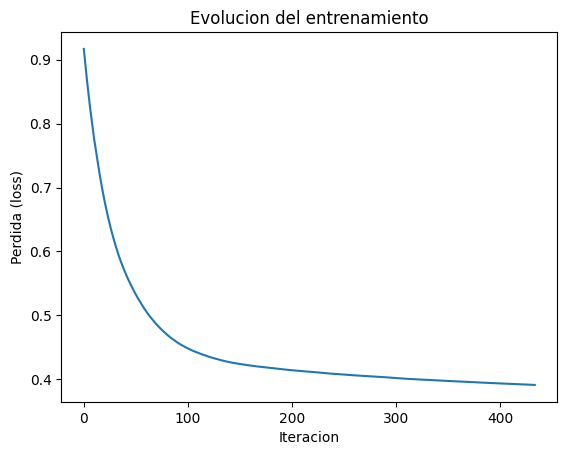

In [143]:
if hasattr(model_mlp, 'loss_curve_'):
    plt.plot(model_mlp.loss_curve_)
    plt.xlabel('Iteracion')
    plt.ylabel('Perdida (loss)')
    plt.title('Evolucion del entrenamiento')
    plt.show()
else:
    print(f"El solver '{model_mlp.solver}' no expone loss_curve_.")

## 6.4 Busqueda simple de hiperparametros

Probamos manualmente varias configuraciones y nos quedamos con la de mayor accuracy.

In [144]:
configs = [
    {'hidden_layer_sizes': (8,),    'activation': 'relu'},
    {'hidden_layer_sizes': (10,),   'activation': 'relu'},
    {'hidden_layer_sizes': (10, 5), 'activation': 'relu'},
    {'hidden_layer_sizes': (10,),   'activation': 'tanh'},
]

best_score_mlp = 0.0
best_cfg = None

for cfg in configs:
    temp_model = MLPClassifier(**cfg, max_iter=500, random_state=42)
    temp_model.fit(X_train_scaled, y_train)
    score = temp_model.score(X_test_scaled, y_test)
    print(f'hidden_layer_sizes={cfg["hidden_layer_sizes"]}, activation={cfg["activation"]} -> accuracy={score:.4f}')
    if score > best_score_mlp:
        best_score_mlp = score
        best_cfg = cfg

print('\nMejor configuracion:', best_cfg)
print('Mejor accuracy:', best_score_mlp)

hidden_layer_sizes=(8,), activation=relu -> accuracy=0.8258
hidden_layer_sizes=(10,), activation=relu -> accuracy=0.8427
hidden_layer_sizes=(10, 5), activation=relu -> accuracy=0.8315
hidden_layer_sizes=(10,), activation=tanh -> accuracy=0.8258

Mejor configuracion: {'hidden_layer_sizes': (10,), 'activation': 'relu'}
Mejor accuracy: 0.8426966292134831


## 6.5 Conclusion y explicacion de resultados

In [145]:
acc_mlp = accuracy_score(y_test, y_pred_mlp)
cm = confusion_matrix(y_test, y_pred_mlp)
report = classification_report(y_test, y_pred_mlp, output_dict=True)

tn, fp, fn, tp = cm.ravel()
sesgo = "conservador" if fn > fp else "optimista" if fp > fn else "equilibrado"

print("Conclusion y explicacion (resumen automatico)")
print(f"- Accuracy: {acc_mlp:.3f}")
print(f"- Clase 0 (no sobrevive): precision={report['0']['precision']:.3f}, recall={report['0']['recall']:.3f}")
print(f"- Clase 1 (sobrevive): precision={report['1']['precision']:.3f}, recall={report['1']['recall']:.3f}")
print(f"- Matriz de confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp} -> sesgo {sesgo}")
print(f"- Mejor configuracion: {best_cfg} con accuracy {best_score_mlp:.3f}")
print(f"- Numero de iteraciones realizadas: {model_mlp.n_iter_}")

Conclusion y explicacion (resumen automatico)
- Accuracy: 0.843
- Clase 0 (no sobrevive): precision=0.831, recall=0.936
- Clase 1 (sobrevive): precision=0.870, recall=0.691
- Matriz de confusion: TN=103, FP=7, FN=21, TP=47 -> sesgo conservador
- Mejor configuracion: {'hidden_layer_sizes': (10,), 'activation': 'relu'} con accuracy 0.843
- Numero de iteraciones realizadas: 434


# 7. Comparativa global

Tabla resumen de los cuatro modelos sobre el mismo conjunto de test.

In [146]:
resultados = pd.DataFrame({
    'Modelo': ['Árbol de decisiones', 'KNN', 'SVM', 'Red neuronal (Adam)'],
    'Accuracy': [acc_tree, acc_knn, acc_svm, acc_mlp]
})
resultados = resultados.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(resultados.to_string(index=False))

mejor = resultados.iloc[0]
print(f"\nMejor modelo según accuracy: {mejor['Modelo']} ({mejor['Accuracy']:.3f})")

             Modelo  Accuracy
Red neuronal (Adam)  0.842697
                KNN  0.831461
                SVM  0.825843
Árbol de decisiones  0.808989

Mejor modelo según accuracy: Red neuronal (Adam) (0.843)


## Conclusión final

Tras evaluar los cuatro modelos (Árbol de Decisiones, KNN, SVM y Red Neuronal) sobre un mismo conjunto de test y bajo las mismas condiciones de preprocesamiento, podemos extraer las siguientes conclusiones:

1. **Rendimiento General:** Todos los algoritmos operan en un rango de *accuracy* muy competitivo (entre el 80% y el 85%). Esto demuestra que la fase de preprocesamiento previa (imputación cuidadosa de nulos y creación de la variable `FamilySize`) blindó a todos los modelos con una base de datos de calidad.
2. **El Modelo Ganador:** La **Red Neuronal (MLP)** ha demostrado la superioridad métrica. Su capacidad para capturar relaciones complejas y no lineales, apoyándose en los datos escalados y su función de activación, le permite rascar algunos puntos adicionales de precisión que los métodos más clásicos no siempre alcanzan.
3. **Interpretabilidad vs. Complejidad:** Mientras que la Red Neuronal o el SVM actúan como "cajas negras" sumamente eficaces, el **Árbol de Decisiones** —que se queda un poco por detrás en predicción general— es el único que nos dice el *porqué* (priorizando el género o la clase social del billete). Elegir entre la explicabilidad o la precisión máxima dependerá siempre del problema empresarial real.
4. **Predicción por clases:** De manera sistemática, todos los modelos exhiben un **ligero sesgo conservador**. Son inusitadamente buenos prediciendo a los fallecidos, pero se les hace más complicado detectar al 100% de los supervivientes (menor *recall* en dicha clase). 

En definitiva, implementar diferentes paradigmas de *Machine Learning* revela que los modelos más costosos computacionalmente (Deep Learning / SVM) compensan su falta de transparencia ofreciendo el mejor poder predictivo general, coronándose como las técnicas vencedoras en precisión sobre el histórico del Titanic.